Partie 1 : Chargement et nettoyage 

On prépare le terrain en chargeant les données et en indiquant à R quelles variables sont des catégories.

In [9]:
# Lecture des données
data <- read.csv('healthcare_synthetic_data.csv')

# Création des nouvelles variables
data$SBMI <- sqrt(data$BMI)
data$SWeight <- sqrt(data$Weight_kg)
data$S_Fasting_Blood_Sugar <- sqrt(data$Fasting_Blood_Sugar)
data$L_Height_cm <- log(data$Height_cm)

# Suppression de la variable Patient_ID et de Heart_Disease_Risk
data$Patient_ID <- NULL
data$Heart_Disease_Risk <- NULL 

# Recodage de la variable Gender en texte puis en facteur
data$Gender <- ifelse(data$Gender == 1, "Male", "Female")

# Conversion des variables qualitatives en facteurs (l'équivalent de "category" / "dummies")
qual_cols <- c("Gender", "Smoking_Status", "Family_History", "Alcohol_Consumption", 
               "Physical_Activity_Level", "Stress_Level", "Sleep_Hours")

for(col in qual_cols) {
  data[[col]] <- as.factor(data[[col]])
}

Interprétation : Ici, on explique à R la nature de nos données. En transformant les colonnes comme Smoking_Status en factor, le modèle mathématique comprendra qu'il s'agit de catégories (Fumeur / Non Fumeur) et non de valeurs numériques (0 et 1) qu'il pourrait faussement additionner. Les transformations (racines carrées, log) permettent de "lisser" les données pour aider le modèle linéaire à trouver des relations proportionnelles.

Visualisation des données:

In [12]:
cat("--- Aperçu des types et valeurs manquantes ---\n")
# str() donne la structure globale (équivalent de info())
str(data)

# Si tu veux aussi compter précisément les valeurs manquantes (NA) par colonne :
cat("\nValeurs manquantes par colonne :\n")
print(colSums(is.na(data)))

cat("\n--- Statistiques descriptives (Numériques) ---\n")
# On filtre pour ne garder que les colonnes numériques
num_cols <- sapply(data, is.numeric)
print(summary(data[, num_cols]))

cat("\n--- Statistiques descriptives (Catégorielles) ---\n")
# On filtre pour ne garder que les colonnes catégorielles (facteurs)
cat_cols <- sapply(data, is.factor)
print(summary(data[, cat_cols]))

--- Aperçu des types et valeurs manquantes ---
'data.frame':	15000 obs. of  21 variables:
 $ Age                    : int  60 53 62 73 52 52 73 64 49 61 ...
 $ Gender                 : Factor w/ 2 levels "Female","Male": 1 1 2 2 2 1 1 1 1 2 ...
 $ Height_cm              : num  147 162 175 173 179 ...
 $ Weight_kg              : num  51.3 76.6 92.4 68.9 79.8 ...
 $ BMI                    : num  23.8 29.3 30.3 22.9 25 23.7 25 34.5 28.2 36.3 ...
 $ Systolic_BP            : int  140 128 141 136 122 134 149 129 139 131 ...
 $ Diastolic_BP           : int  89 81 100 96 80 92 98 90 91 91 ...
 $ Cholesterol_Total      : int  217 203 173 193 236 225 260 237 227 206 ...
 $ Cholesterol_LDL        : int  151 119 124 117 153 155 166 160 138 139 ...
 $ Cholesterol_HDL        : int  52 38 45 45 41 48 46 44 37 38 ...
 $ Fasting_Blood_Sugar    : int  83 116 90 81 79 103 103 108 90 103 ...
 $ Smoking_Status         : Factor w/ 2 levels "0","1": 1 1 1 1 1 1 1 1 2 1 ...
 $ Alcohol_Consumption    : Factor 

Partie 2 : Variable cible et visualisation

On regarde ce qu'on essaie de prédire.

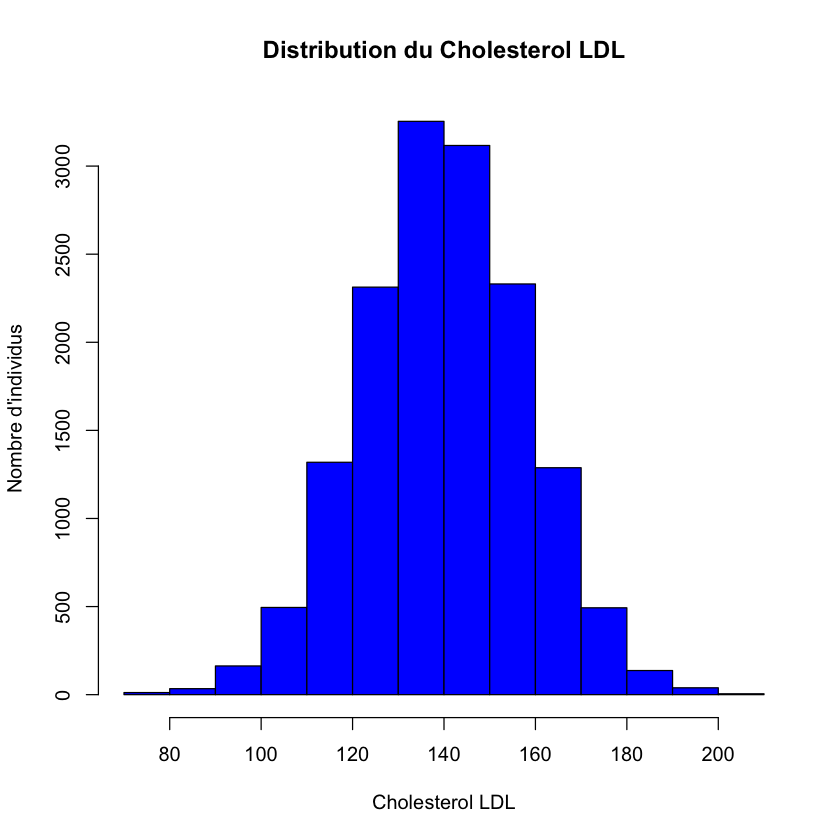

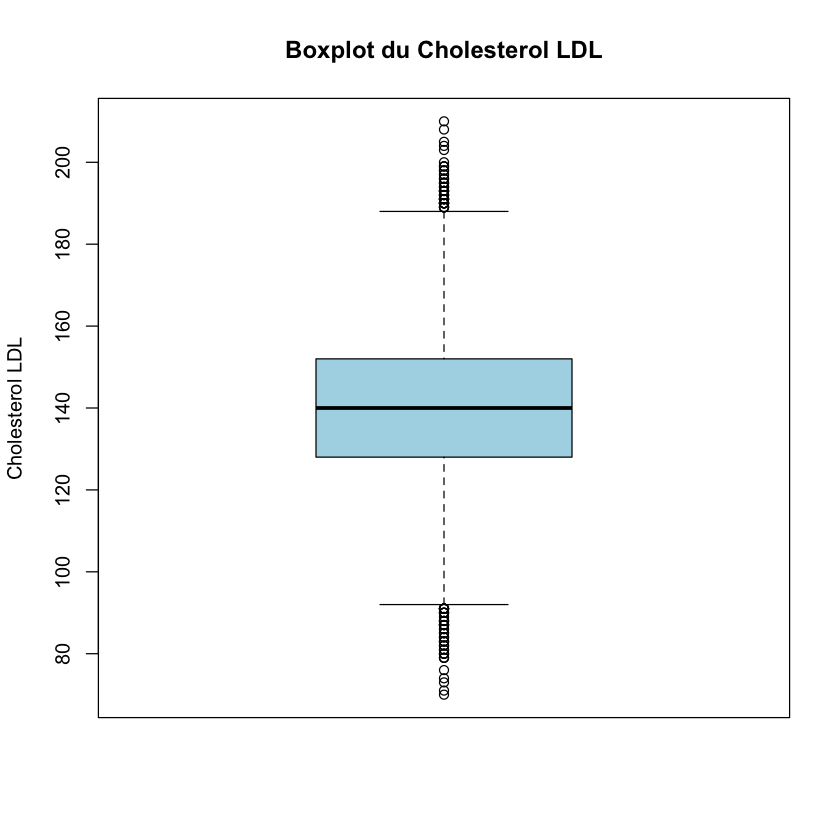

In [11]:
# On isole la variable cible pour vérifier sa distribution
y <- data$Cholesterol_LDL

hist(y, 
     main="Distribution du Cholesterol LDL", 
     xlab="Cholesterol LDL", 
     ylab="Nombre d'individus", 
     col="blue", 
     border="black")


# Création du boxplot pour repérer les valeurs aberrantes (outliers)
boxplot(y, 
        main="Boxplot du Cholesterol LDL", 
        ylab="Cholesterol LDL", 
        col="lightblue")

Analyse de la distribution : (graphe 1)

Ce qu'on observe : La distribution de la variable prend une très belle forme en "cloche" (loi normale ou distribution gaussienne). Le pic central se situe très exactement autour de la moyenne (qui est d'environ 140 mg/dL).

L'interprétation : L'échantillon est très bien réparti et symétrique. Il n'y a pas de déséquilibre majeur (asymétrie) qui tirerait la moyenne vers le haut ou vers le bas.

L'impact pour le projet : Le modèle sera beaucoup plus stable et fiable dans ses prédictions.


Analyse du boxplot : (graphe 2)

Ce qu'on observe : La médiane (le trait noir épais au milieu de la boîte) est parfaitement centrée, ce qui confirme la symétrie. La boîte bleue elle-même concentre 50 % des patients (l'écart interquartile), qui ont tous un "mauvais" cholestérol compris entre 128 et 152 mg/dL.

Les valeurs aberrantes (Outliers) : Au-dessus de la moustache du haut et en dessous de celle du bas, il y a des petits cercles isolés. Ils correspondent aux valeurs extrêmes (les minimums descendent jusqu'à 70 mg/dL et les maximums montent jusqu'à 210 mg/dL).

L'interprétation : Ces "outliers" représentent des patients avec des taux cliniquement très atypiques par rapport au reste du jeu de données.

L'impact pour le projet : En régression linéaire, les valeurs extrêmes tirent parfois la "droite" de prédiction vers elles, ce qui peut créer des petites erreurs. Cependant, en contexte médical, on ne supprime généralement pas ces patients car ils existent dans la vraie vie ! Le modèle fera juste des erreurs de prédiction un tout petit peu plus grandes sur eux.

Etape 3 : Séparation : Train / Test 

On cache une partie des données pour tester le modèle de manière impartiale.

In [5]:
# Fixer la graine aléatoire pour la reproductibilité
set.seed(42)

n <- nrow(data)
# Tirage de 80% des indices pour le train
train_indices <- sample(1:n, size = 0.8 * n)

# Création des échantillons
X_train <- data[train_indices, ]
X_test <- data[-train_indices, ]

cat("Taille de l'échantillon d'apprentissage :", nrow(X_train), "individus\n")
cat("Taille de l'échantillon de test :", nrow(X_test), "individus\n")

Taille de l'échantillon d'apprentissage : 12000 individus
Taille de l'échantillon de test : 3000 individus


Interprétation :

On simule l'arrivée de futurs patients. Le modèle va s'entraîner sur les 80% (Train) pour comprendre le lien entre le mode de vie et le cholestérol. Ensuite, on le testera sur les 20% restants (Test) en lui cachant leur vrai taux de cholestérol pour voir s'il devine juste.


Étape 4 : Standardisation (Mise à l'échelle)

On met toutes les variables numériques sur le même pied d'égalité.

In [13]:
# Liste des variables quantitatives à standardiser (on exclut la cible Cholesterol_LDL)
quant_cols <- c("SBMI", "SWeight", "S_Fasting_Blood_Sugar", "L_Height_cm", 
                "Age", "Systolic_BP", "Diastolic_BP", "Cholesterol_Total", "Cholesterol_HDL")

X_train_scaled <- X_train
X_test_scaled <- X_test

# Calcul de la moyenne et de l'écart-type sur le Train
moyennes_train <- apply(X_train[, quant_cols], 2, mean)
ecart_types_train <- apply(X_train[, quant_cols], 2, sd)

# Application de la standardisation
X_train_scaled[, quant_cols] <- scale(X_train[, quant_cols], center = moyennes_train, scale = ecart_types_train)
X_test_scaled[, quant_cols]  <- scale(X_test[, quant_cols],  center = moyennes_train, scale = ecart_types_train)

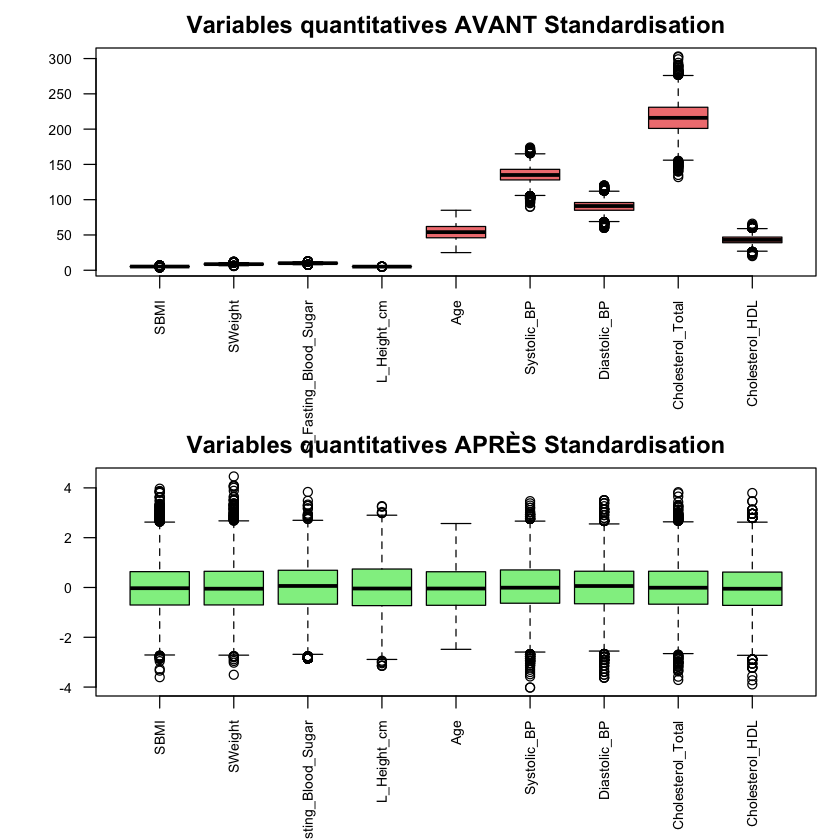

In [16]:
# Astuce pour l'affichage : on coupe l'écran en 2 (haut et bas)
# et on ajuste les marges pour laisser la place aux noms des variables
par(mfrow=c(2, 1), mar=c(6, 4, 2, 1))

# 1. Boxplot AVANT standardisation
boxplot(X_train[, quant_cols], 
        main="Variables quantitatives AVANT Standardisation", 
        col="lightcoral", 
        las=2,         # las=2 permet de mettre les noms des axes à la verticale
        cex.axis=0.7)  # Réduit un peu la taille du texte

# 2. Boxplot APRÈS standardisation
boxplot(X_train_scaled[, quant_cols], 
        main="Variables quantitatives APRÈS Standardisation", 
        col="lightgreen", 
        las=2, 
        cex.axis=0.7)

# On remet l'affichage à la normale (1 graphique complet)
par(mfrow=c(1, 1), mar=c(5, 4, 4, 2) + 0.1)

Conclusion : 

Cette mise à l'échelle garantit que le modèle de régression linéaire évaluera chaque caractéristique clinique de manière parfaitement équitable. L'algorithme pourra ainsi estimer ses coefficients de manière stable et trouver la véritable corrélation entre chaque variable et le cholestérol LDL, sans être perturbé par des questions d'unités de grandeur.